# Treinamento 6 - Machine Learning: Julio Cesar Menescal

## Parte 1.1 - EDA (Regressão)

In [464]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("regressao/train.csv")

In [465]:
df.shape

(395, 31)

In [466]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67


In [467]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   age         395 non-null    int64  
 3   address     395 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    object 
 19  nursery     395 non-null    o

In [468]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,score
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.679139
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.696912
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.330000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.330000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,10.670000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.330000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.330000


In [469]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
score         0
dtype: int64

<Axes: xlabel='score', ylabel='Count'>

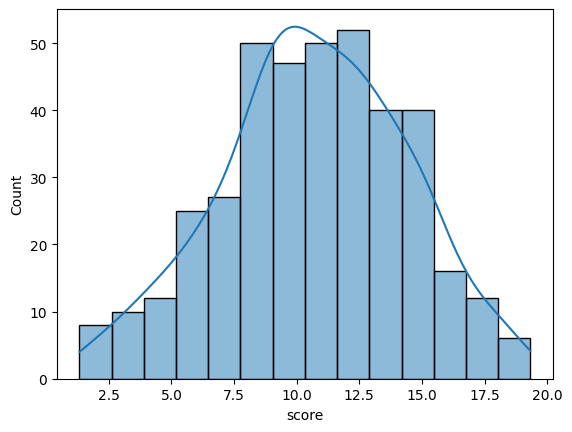

In [470]:
# ANÁLISE DA DISTRIBUIÇÃO DA VARIÁVEL ALVO

sns.histplot(df["score"], kde=True)

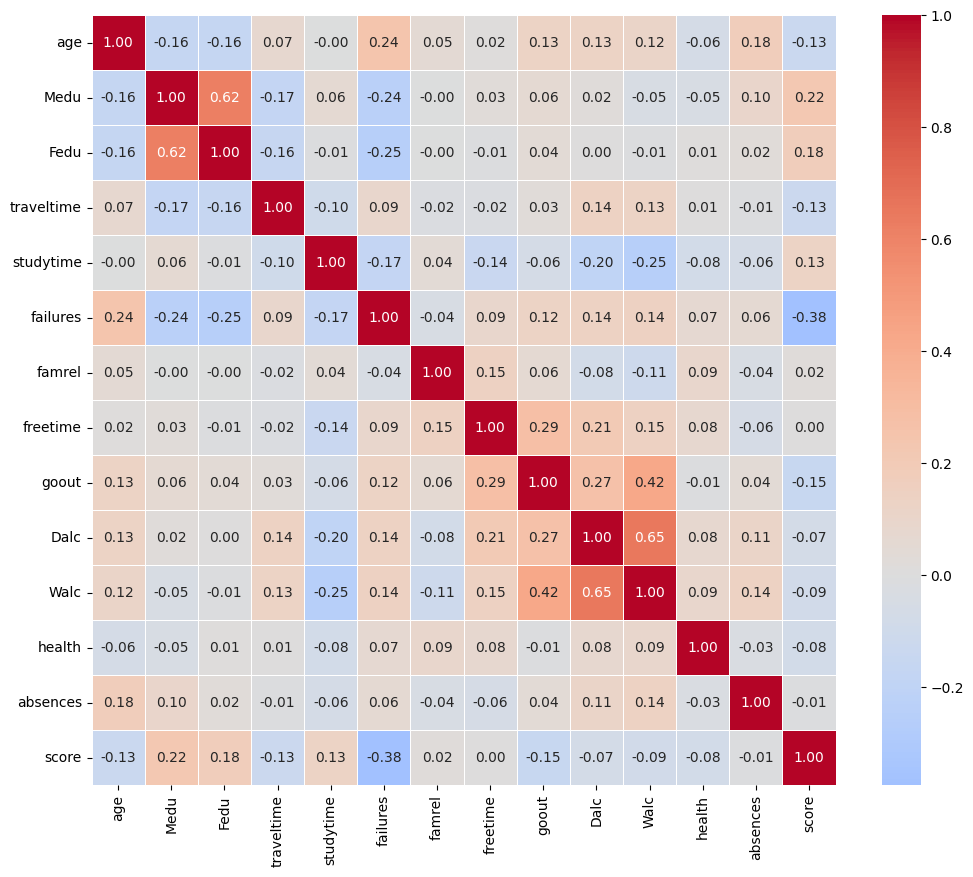

In [471]:
# CORRELAÇÃO

plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,      
    fmt=".2f",       
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.show()

In [472]:
# VARIÁVEIS CATEGÓRICAS

df.select_dtypes(include="object").columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [473]:
# FREQUÊNCIA DAS VARIÁVEIS ORDINÁRIAS

for col in df.select_dtypes(include="object"):
    print(f"\n{col}")
    print(df[col].value_counts())


school
school
GP    349
MS     46
Name: count, dtype: int64

sex
sex
F    208
M    187
Name: count, dtype: int64

address
address
U    307
R     88
Name: count, dtype: int64

famsize
famsize
GT3    281
LE3    114
Name: count, dtype: int64

Pstatus
Pstatus
T    354
A     41
Name: count, dtype: int64

Mjob
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

Fjob
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

reason
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

guardian
guardian
mother    273
father     90
other      32
Name: count, dtype: int64

schoolsup
schoolsup
no     344
yes     51
Name: count, dtype: int64

famsup
famsup
yes    242
no     153
Name: count, dtype: int64

paid
paid
no     214
yes    181
Name: count, dtype: int64

activities
activities
yes    201
no     194
Name: count, dtype: int64

nu

In [474]:
# FREQUÊNCIA DAS VARIÁVEIS NUMÉRICAS

colunas = [
    "Medu", "Fedu", "studytime",
    "traveltime", "failures",
    "famrel", "freetime",
    "goout", "Dalc", "Walc",
    "health"
]

for col in colunas:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


Medu
Medu
0      3
1     59
2    103
3     99
4    131
Name: count, dtype: int64

Fedu
Fedu
0      2
1     82
2    115
3    100
4     96
Name: count, dtype: int64

studytime
studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

traveltime
traveltime
1    257
2    107
3     23
4      8
Name: count, dtype: int64

failures
failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64

famrel
famrel
1      8
2     18
3     68
4    195
5    106
Name: count, dtype: int64

freetime
freetime
1     19
2     64
3    157
4    115
5     40
Name: count, dtype: int64

goout
goout
1     23
2    103
3    130
4     86
5     53
Name: count, dtype: int64

Dalc
Dalc
1    276
2     75
3     26
4      9
5      9
Name: count, dtype: int64

Walc
Walc
1    151
2     85
3     80
4     51
5     28
Name: count, dtype: int64

health
health
1     47
2     45
3     91
4     66
5    146
Name: count, dtype: int64


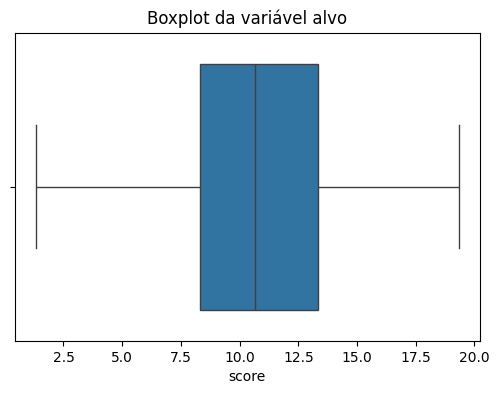

In [475]:
# VERIFICAÇÃO DE OUTLIERS

plt.figure(figsize=(6,4))

sns.boxplot(x=df["score"])

plt.title("Boxplot da variável alvo")
plt.show()

### Conclusão da EDA

- O conjunto não apresenta valores nulos.

- Não há linhas duplicadas.

- A variável alvo possui concentração alta entre 9 e 13 pontos e não há outliers.

- Há 17 variáveis categóricas e 14 numéricas.

Correlações:

- failures apresentou alta correlação com socre, indicando que alunos com mais reprovações tendem a ter notas menores.

- Medu e Fedu, apresentaram correlação positiva com a nota, sugerindo que maior escolaridade dos pais está associada a melhor desempenho acadêmico.

- sutdytime apresentou relação positiva, porém fraca.

## Parte 1.2 - Pré-Processamento dos dados

In [476]:
X = df.drop(columns="score") # ENTRADA
Y = df["score"] # SAÍDA

In [477]:
from sklearn.model_selection import train_test_split

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [478]:
# TIPOS DE COLUNA

categoricas = X_train.select_dtypes(include="object").columns

numericas = X_train.select_dtypes(exclude="object").columns

print(categoricas)
print(numericas)

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences'],
      dtype='object')


In [479]:
# PADRONIZAÇÃO DAS CATEGÓRICAS
from sklearn.preprocessing import OneHotEncoder

# PADRONIZAÇÃO DAS NUMÉRICAS
from sklearn.preprocessing import StandardScaler

# PARA PRÉ-PROCESSADOR
from sklearn.compose import ColumnTransformer

#PARA PIPELINE
from sklearn.pipeline import Pipeline

In [480]:
# PRÉ-PROCESSADOR

preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas)
    ]
)

# Parte 1.3 - Modelos de Regressão

In [481]:
# importando o metodo de avaliacao de erros

from sklearn.metrics import root_mean_squared_error

In [482]:
# RANDOM FOREST REGRESSOR
from sklearn.ensemble import RandomForestRegressor

pipeline_RandomForest = Pipeline([("preprocessamento", preprocessador), ("modelo", RandomForestRegressor(random_state=42))])

pipeline_RandomForest.fit(X_train, Y_train)

,steps,"[('preprocessamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [483]:
Y_pred = pipeline_RandomForest.predict(X_valid)

In [484]:
rmse_forest = root_mean_squared_error(Y_valid, Y_pred)

print(f"RMSE Random Forest: {rmse_forest:.4f}")

RMSE Random Forest: 3.2544


In [485]:
# LINEAR REGRESSION

from sklearn.linear_model import LinearRegression

pipeline_LinearRegression= Pipeline([("preprocessamento", preprocessador), ("modelo", LinearRegression())])

pipeline_LinearRegression.fit(X_train, Y_train)

,steps,"[('preprocessamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [486]:
Y_pred = pipeline_LinearRegression.predict(X_valid)

In [487]:
rmse_linear = root_mean_squared_error(Y_valid, Y_pred)

print(f"RMSE Linear Regression: {rmse_linear:.4f}")

RMSE Linear Regression: 3.3750


In [488]:
# RIDGE

from sklearn.linear_model import Ridge

pipeline_Ridge = Pipeline([("preprocessamento", preprocessador), ("modelo", Ridge(alpha= 1.0))])

pipeline_Ridge.fit(X_train, Y_train)

,steps,"[('preprocessamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [489]:
Y_pred = pipeline_Ridge.predict(X_valid)

In [490]:
rmse_ridge = root_mean_squared_error(Y_valid, Y_pred)

print(f"RMSE Ridge: {rmse_ridge:.4f}")

RMSE Ridge: 3.3723


In [491]:
from sklearn.ensemble import GradientBoostingRegressor

pipeline_Gb = Pipeline([("preprocessamento", preprocessador), ("modelo", GradientBoostingRegressor(random_state=42))])

pipeline_Gb.fit(X_train, Y_train)

,steps,"[('preprocessamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [492]:
Y_pred = pipeline_Gb.predict(X_valid)

In [493]:
rmse_gb = root_mean_squared_error(Y_valid, Y_pred)

print(f"RMSE Gradient Boosting: {rmse_gb:.4f}")

RMSE Gradient Boosting: 3.2626


### Comparação dos Resultados

In [494]:
resultados = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "Linear Regression",
        "Ridge",
        "Gradient Boosting"
    ],
    "RMSE": [
        rmse_forest,
        rmse_linear,
        rmse_ridge,
        rmse_gb
    ]
})

resultados.sort_values("RMSE")

,Modelo,RMSE
0,Random Forest,3.254409
3,Gradient Boosting,3.262648
2,Ridge,3.372275
1,Linear Regression,3.374966


## Conclusão

Foram avaliados quatro modelos de regressão utilizando o RMSE como métrica de desempenho. O Random Forest apresentou o menor erro (RMSE = 3,2544), seguido de perto pelo Gradient Boosting (RMSE = 3,2626). Os modelos lineares (Linear Regression e Ridge) obtiveram desempenho inferior. Esses resultados sugerem que a relação entre as variáveis explicativas e a nota dos alunos apresenta componentes não lineares, melhor capturados pelos modelos baseados em árvores. Dessa forma, o Random Forest foi selecionado como modelo final para gerar as previsões do conjunto de teste.

# Parte 1.4 - Treinamento do Conjunto

In [495]:
# TREINAR O CONJUNTO TODO

melhor_modelo = Pipeline([("preprocessamento", preprocessador), ("modelo", RandomForestRegressor(random_state=42))])

melhor_modelo.fit(X, Y)

,steps,"[('preprocessamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [496]:
df_teste = pd.read_csv("regressao/test.csv")

In [497]:
predicoes = melhor_modelo.predict(df_teste)

### Arquivo de submissão ao Kaggle

In [498]:
modelo_final_gb = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", GradientBoostingRegressor(random_state=42))
])

modelo_final_gb.fit(X, Y)

,steps,"[('preprocessamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [499]:
predicoes_gb = modelo_final_gb.predict(df_teste)

In [500]:
submission_gb = pd.DataFrame({
    "id": range(len(predicoes_gb)),
    "score": predicoes_gb
})

submission_gb.to_csv(
    "submission_gradient_boosting.csv",
    index=False
)

## Conclusão

O modelo escolhido para ser subetido ao Kaggle foi o Gradient Boost (submission_gradient_boosting.csv), pelo seu melhor desempenho no ranking da competição e baixa diferença de RMSE em relação ao Random Forest.

# Parte 2.1 - EDA (Classificação)

In [501]:
df_class = pd.read_csv("classiicacao/train2.csv")

In [502]:
df_class.shape

(569, 31)

In [503]:
df_class.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [504]:
df_class.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [505]:
df_class.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [506]:
# Distribuicao do alvo

df_class["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [507]:
df_class["diagnosis"].value_counts(normalize=True) * 100

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

In [508]:
df_class.duplicated().sum()

np.int64(0)

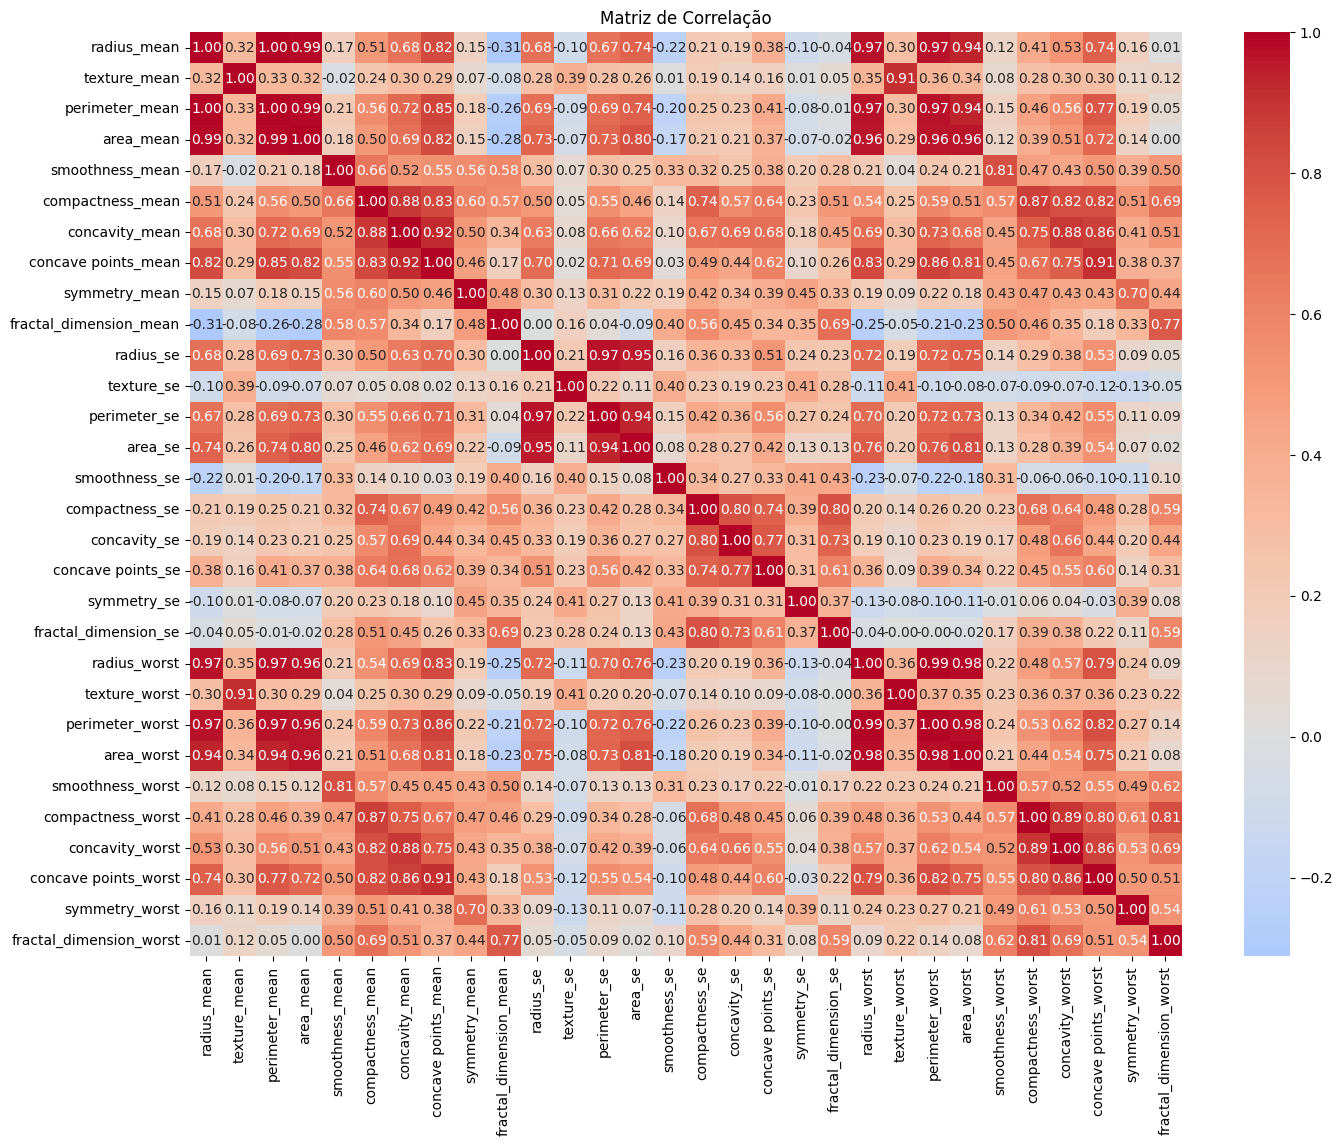

In [509]:
# CORRELAÇÃO

plt.figure(figsize=(16,12))

sns.heatmap(
    df_class.drop(columns="diagnosis").corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação")
plt.show()

In [510]:
df_corr = df_class.copy()

df_corr["diagnosis"] = df_corr["diagnosis"].map({
    "B": 0,
    "M": 1
})

corr_target = (
    df_corr.corr()["diagnosis"]
    .sort_values(ascending=False)
)

corr_target

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

## Conclusão da EDA

A análise de correlação mostrou que características relacionadas ao tamanho e à irregularidade do tumor apresentam maior associação com o diagnóstico maligno. As variáveis concave_points_worst, perimeter_worstm, radius_worst, perimeter_mean e area_worst apresentaram as maiores correlações positivas com a variável alvo. Além disso, observou-se forte correlação entre diversas variáveis preditoras, especialmente entre medidas de raio, perímetro e área, indicando multicolinearidade.

# Parte 2.2 - Pré-Processamento dos dados

In [511]:
X = df_class.drop(columns="diagnosis") #ENTRADA
Y = df_class["diagnosis"] #SAÍDA

In [512]:
from sklearn.model_selection import train_test_split

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [513]:
# PADRONIZAÇÃO DAS NUMÉRICAS
from sklearn.preprocessing import StandardScaler

# PARA PIPELINE
from sklearn.pipeline import Pipeline

# ANÁLISES

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score
)

In [514]:
colunas_numericas = X.columns.tolist()

preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas)
    ]
)

# Parte 2.3 - Modelos de Classificação

In [515]:
# LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

pipeline_log = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", LogisticRegression(random_state=42))
])

pipeline_log.fit(X_train, Y_train)

,steps,"[('preprocessamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [516]:
Ypred_log = pipeline_log.predict(X_valid)

In [517]:
# ACURÁCIA

acc_log = accuracy_score(Y_valid, Ypred_log)

print(f"Accuracy: {acc_log:.4f}")

Accuracy: 0.9649


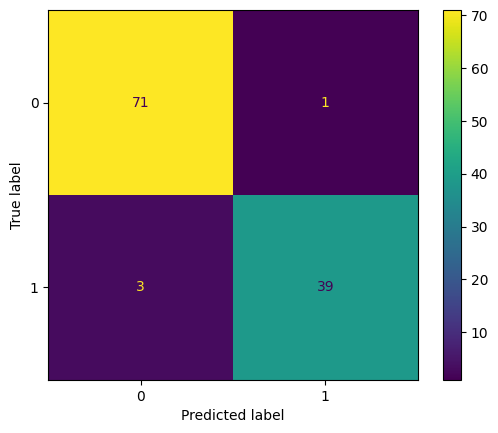

In [518]:
# MATRIZ DE CONFUSÃO

cm_log = confusion_matrix(Y_valid, Ypred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.show()

In [519]:
# CLASSIFICATION REPORT

print(classification_report(Y_valid, Ypred_log))

              precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [520]:
Y_prob_log = pipeline_log.predict_proba(X_valid)[:, 1]

In [521]:
# ROC-AUC

y_valid_bin = Y_valid.map({
    "B": 0,
    "M": 1
})

roc_log = roc_auc_score(y_valid_bin, Y_prob_log)

print(f"ROC-AUC: {roc_log:.4f}")

ROC-AUC: 0.9960


In [522]:
# RANDOM FOREST CLASSIFIER

from sklearn.ensemble import RandomForestClassifier

pipeline_forest = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

pipeline_forest.fit(X_train, Y_train)

,steps,"[('preprocessamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [523]:
Y_pred_forest = pipeline_forest.predict(X_valid)

In [524]:
acc_forest = accuracy_score(Y_valid, Y_pred_forest)

print(f"Accuracy Random Forest: {acc_forest:.4f}")

Accuracy Random Forest: 0.9737


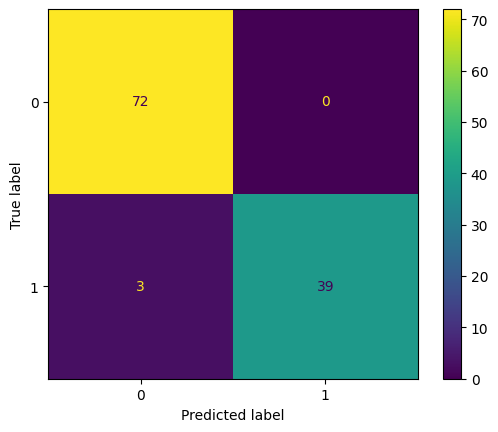

In [525]:
cm_forest = confusion_matrix(Y_valid, Y_pred_forest)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_forest)
disp.plot()

plt.show()

In [526]:
print(classification_report(Y_valid, Y_pred_forest))

              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [527]:
# ROC-AUC

Y_prob_forest = pipeline_forest.predict_proba(X_valid)[:, 1]

y_valid_bin = Y_valid.map({
    "B": 0,
    "M": 1
})

roc_forest = roc_auc_score(y_valid_bin, Y_prob_forest)

print(f"ROC-AUC Random Forest: {roc_forest:.4f}")

ROC-AUC Random Forest: 0.9929


In [528]:
# GRADIENT BOOST CLASSIFIER

from sklearn.ensemble import GradientBoostingClassifier

pipeline_gb = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", GradientBoostingClassifier(
        random_state=42
    ))
])

pipeline_gb.fit(X_train, Y_train)

,steps,"[('preprocessamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [529]:
Y_pred_gb = pipeline_gb.predict(X_valid)

In [530]:
acc_gb = accuracy_score(Y_valid, Y_pred_gb)

print(f"Accuracy Gradient Boosting: {acc_gb:.4f}")

Accuracy Gradient Boosting: 0.9649


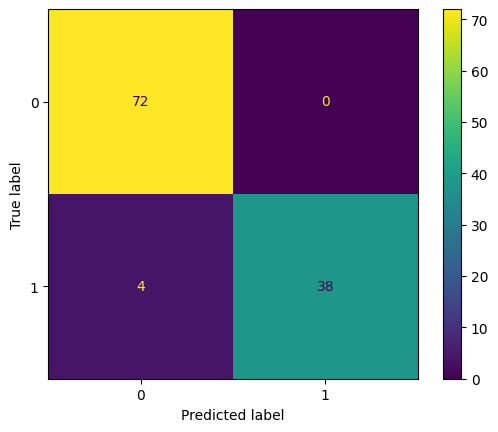

In [531]:
cm_gb = confusion_matrix(Y_valid, Y_pred_gb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp.plot()

plt.show()

In [532]:
print(classification_report(Y_valid, Y_pred_gb))

              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [533]:
# ROC-AUC

Y_prob_gb = pipeline_gb.predict_proba(X_valid)[:, 1]

roc_gb = roc_auc_score(y_valid_bin, Y_prob_gb)

print(f"ROC-AUC Gradient Boosting: {roc_gb:.4f}")

ROC-AUC Gradient Boosting: 0.9947


In [534]:
# COMPARAÇÃO

comparacao = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        acc_log,
        acc_forest,
        acc_gb
    ],
    "ROC-AUC": [
        roc_log,
        roc_forest,
        roc_gb
    ]
})

comparacao.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Modelo,Accuracy,ROC-AUC
0,Logistic Regression,0.964912,0.996032
2,Gradient Boosting,0.964912,0.994709
1,Random Forest,0.973684,0.992890


# Parte 2.4 - Treinamento do Conjunto

In [535]:
# TREINAMENTO DO CONJUNTO TODO

X = df_class.drop(columns="diagnosis")
Y = df_class["diagnosis"]

pipeline_forest.fit(X, Y)

,steps,"[('preprocessamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [536]:
# Treinar com todo o conjunto
pipeline_log.fit(X, Y)

# Prever o teste
pred_log = pipeline_log.predict(df_test2)

# Converter para 0 e 1
pred_log_num = pd.Series(pred_log).map({
    "B": 0,
    "M": 1
})

# Criar submissão
submission_log = pd.DataFrame({
    "id": range(len(pred_log_num)),
    "diagnosis": pred_log_num
})

submission_log.to_csv(
    "submission_classificacao_logistic.csv",
    index=False
)

## Conclusão

Foram avaliados os modelos Regressão Logística, Random Forest e Gradient Boosting. Todos apresentaram desempenho elevado, com acurácia superior a 96% e ROC-AUC acima de 0,99. Embora o Random Forest tenha obtido a maior acurácia no conjunto de validação (97,37%), a Regressão Logística apresentou o maior ROC-AUC (0,9960) e também o melhor desempenho na avaliação do Kaggle. Dessa forma, a Regressão Logística foi selecionada como modelo final para a geração das previsões do conjunto de teste.

# Parte 3 - Conclusão Geral

Ao longo desta atividade, foi possível percorrer todas as etapas de um projeto de Machine Learning, desde a compreensão dos dados até a seleção dos modelos finais. A análise exploratória foi fundamental para entender as características de cada conjunto de dados e orientar as decisões tomadas durante o desenvolvimento.

Um dos pontos mais interessantes foi perceber que o modelo com melhor desempenho na validação local nem sempre é o que apresenta os melhores resultados em dados completamente novos. Isso ficou evidente nas submissões ao Kaggle, que serviram como uma avaliação mais próxima de um cenário real.

Na regressão, o Gradient Boosting foi o modelo que apresentou o melhor desempenho final. Já na classificação, a Regressão Logística se destacou, mostrando que modelos relativamente simples podem alcançar resultados excelentes quando bem aplicados. De forma geral, a atividade reforçou a importância de testar diferentes abordagens, interpretar as métricas corretamente e utilizar evidências para justificar a escolha do modelo final, em vez de assumir que uma única técnica será sempre a melhor solução.